In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
torch.tensor([5.0]).var(0, correction=0) # https://discuss.pytorch.org/t/torch-var-and-torch-std-return-nan/38884/3

tensor(0.)

In [ ]:
names = open("names.txt", "r").read().splitlines()
print(len(names))
print(names[:8])

32033
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [ ]:
chars = sorted(list(set(''.join(names))))

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

vocab_size = len(stoi)

print(stoi)
print(vocab_size)


{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}
27


In [ ]:
import random
random.seed(42)
random.shuffle(names)

# Performance Log


*   Original: context length of 3 + hidden size 200 (~12K params)
      train (2.058725118637085)
      val (2.1081695556640625)
*   Update 1: context length increased to 8 + hidden size 200 (~22K params)
      train (1.9176347255706787)
      val (2.0230932235717773)

*   Update 2: wavenet - context 8 + hidden size 68 (~22K params)
      train 1.9392313957214355
      val 2.030489683151245

*   Update 3: BatchNorm feature update - to handle multi-dimensional aggregation
      train 1.9120763540267944
      val 2.017792224884033

*   Update 4: Increase number of parameters (~76K params)
      train 1.767202615737915
      val 1.9940412044525146








In [ ]:
block_size = 3


def build_dataset(names):

  x = []
  y = []
  for name in names:
    context = [0]* block_size
    for ch in name + '.':
      ix = stoi[ch]
      x.append(context)
      y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(x)
  Y = torch.tensor(y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(len(names)*0.8)
n2 = int(len(names)*0.9)
xTr, yTr = build_dataset(names[:n1])
xDev, yDev = build_dataset(names[n1:n2])
xTe, yTe = build_dataset(names[n2:])


torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
for x,y in zip(xTr[:10], yTr[:10]):
  print(''.join([itos[ix.item()] for ix in x]),  '-->',  itos[y.item()])

... --> y
..y --> u
.yu --> h
yuh --> e
uhe --> n
hen --> g
eng --> .
... --> d
..d --> i
.di --> o


In [ ]:
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weights = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.randn(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weights
    if self.bias is not None:
      self.out += self.bias

    return self.out

  def parameters(self):
    return [self.weights] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training =True

    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):

    if self.training:
      bmean = x.mean(0, keepdim=True)
      bvar = x.var(0, keepdim=True)
    else:
      bmean = self.running_mean
      bvar = self.running_var

    xhat = (x - bmean)/torch.sqrt(bvar + self.eps)
    self.out = self.gamma * xhat + self.beta

    if self.training:
      with torch.no_grad():
        self.running_mean = self.momentum*bmean + (1-self.momentum) * self.running_mean
        self.running_var = self.momentum*bvar + (1-self.momentum) * self.running_var

    return self.out

  def parameters(self):
    return [self.gamma] + [self.beta]


class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


In [ ]:
torch.manual_seed(42)

In [ ]:
embed_size = 10
hidden_size = 200


C = torch.randn((vocab_size, embed_size))

layers = [
    Linear(block_size*embed_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, vocab_size),
]

with torch.no_grad():
  layers[-1].weights *= 0.1 # lowered to avoid imbalanaced output probabilities coz that mean higher initial loss, hockey stick issue

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True



12097


In [ ]:
num_epochs = 200000
batch_size = 32

lossi = []


for i in range(num_epochs):

  ix = torch.randint(0, xTr.shape[0], (batch_size, ))
  xB, yB = xTr[ix], yTr[ix]

  # forward pass
  embed = C[xB]
  x = embed.view(-1, embed_size * block_size)
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yB)

  # backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  # update
  lr = 0.1 if i<150000 else 0.01

  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{num_epochs:7d}: {loss.item():.4f}')
    # print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

  lossi.append(loss.log10().item())



      0/ 200000: 3.6123
  10000/ 200000: 2.2514
  20000/ 200000: 2.2134
  30000/ 200000: 2.1166
  40000/ 200000: 2.4739
  50000/ 200000: 1.9872
  60000/ 200000: 1.7952
  70000/ 200000: 2.3035
  80000/ 200000: 2.1824
  90000/ 200000: 2.1404
 100000/ 200000: 2.1920
 110000/ 200000: 2.2182
 120000/ 200000: 1.9509
 130000/ 200000: 2.1866
 140000/ 200000: 2.5230
 150000/ 200000: 2.2446
 160000/ 200000: 1.9806
 170000/ 200000: 1.8113
 180000/ 200000: 1.8983
 190000/ 200000: 1.7139


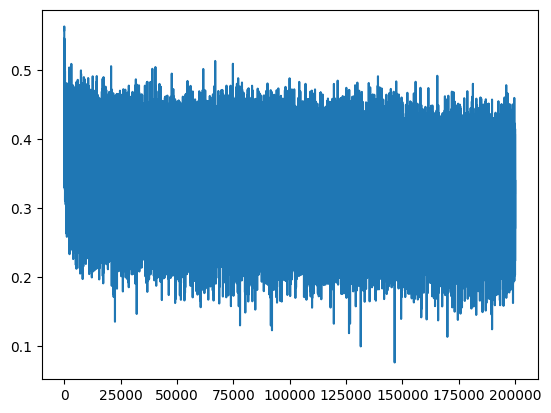

In [ ]:
plt.plot(lossi)

In [ ]:
# put layers into eval mode before running evaluations
for layer in layers:
  layer.training = False

In [ ]:
# evaluate

@torch.no_grad()
def split_loss(split):
  x, y = {
      'train': (xTr, yTr),
      'val': (xDev, yDev),
      'test': (xTe, yTe)
  }[split]
  embed = C[x]
  x = embed.view(-1, embed_size * block_size)
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.058725118637085
val 2.1081695556640625


In [ ]:
embed_size * block_size

30

In [ ]:
with torch.no_grad():
  for _ in range(20):
    out = []

    context = [0]*block_size

    while True:
      emb = C[torch.tensor(context)]
      x = emb.view(-1, embed_size * block_size)
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      out.append(itos[ix])
      context = context[1:] + [ix]
      if ix == 0:
        break

    print(''.join(out))

jastielle.
cani.
ciaub.
alitithira.
liza.
jah.
grancealynna.
jamark.
ben.
quan.
torie.
coria.
cer.
tyre.
dia.
beir.
damelays.
kascacolton.
edinicia.
dhira.


# Improvements

## Improvement 1

loss curve represented on average

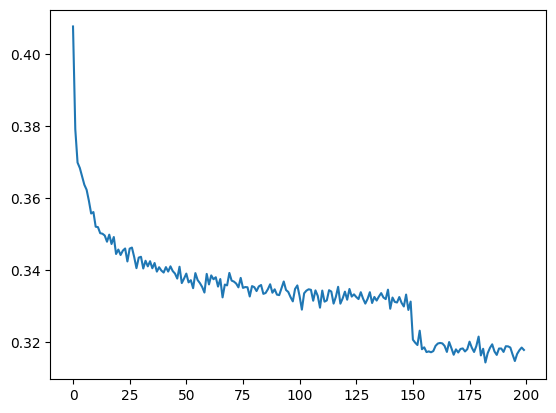

In [ ]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

## Improvement 2

Make all steps in the forward pass a LAYER

In [ ]:
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weights = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.randn(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weights
    if self.bias is not None:
      self.out += self.bias

    return self.out

  def parameters(self):
    return [self.weights] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training =True

    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):

    if self.training:
      bmean = x.mean(0, keepdim=True)
      bvar = x.var(0, keepdim=True)
    else:
      bmean = self.running_mean
      bvar = self.running_var

    xhat = (x - bmean)/torch.sqrt(bvar + self.eps)
    self.out = self.gamma * xhat + self.beta

    if self.training:
      with torch.no_grad():
        self.running_mean = self.momentum*bmean + (1-self.momentum) * self.running_mean
        self.running_var = self.momentum*bvar + (1-self.momentum) * self.running_var

    return self.out

  def parameters(self):
    return [self.gamma] + [self.beta]


class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


class Embedding:
  def __init__(self, vocab_size, embed_size):
    self.weights = torch.randn((vocab_size, embed_size))

  def __call__(self, ix):
    self.out = self.weights[ix]

    return self.out

  def parameters(self):
    return [self.weights]


class Flatten:
  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out

  def parameters(self):
    return []

In [ ]:
torch.manual_seed(42)

In [ ]:
embed_size = 10
hidden_size = 200


layers = [
    Embedding(vocab_size, embed_size),
    Flatten(),
    Linear(block_size*embed_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, vocab_size),
]

with torch.no_grad():
  layers[-1].weights *= 0.1 # lowered to avoid imbalanaced output probabilities coz that mean higher initial loss, hockey stick issue

parameters = [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

12097


In [ ]:
num_epochs = 200000
batch_size = 32

lossi = []


for i in range(num_epochs):

  ix = torch.randint(0, xTr.shape[0], (batch_size, ))
  xB, yB = xTr[ix], yTr[ix]

  # forward pass
  x = xB
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yB)

  # backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  # update
  lr = 0.1 if i<150000 else 0.01

  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{num_epochs:7d}: {loss.item():.4f}')
    # print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

  lossi.append(loss.log10().item())

  break



      0/ 200000: 3.6123


## Improvement 3

Add Sequential container

In [ ]:
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weights = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.randn(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weights
    if self.bias is not None:
      self.out += self.bias

    return self.out

  def parameters(self):
    return [self.weights] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training =True

    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):

    if self.training:
      bmean = x.mean(0, keepdim=True)
      bvar = x.var(0, keepdim=True)
    else:
      bmean = self.running_mean
      bvar = self.running_var

    xhat = (x - bmean)/torch.sqrt(bvar + self.eps)
    self.out = self.gamma * xhat + self.beta

    if self.training:
      with torch.no_grad():
        self.running_mean = self.momentum*bmean + (1-self.momentum) * self.running_mean
        self.running_var = self.momentum*bvar + (1-self.momentum) * self.running_var

    return self.out

  def parameters(self):
    return [self.gamma] + [self.beta]


class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


class Embedding:
  def __init__(self, vocab_size, embed_size):
    self.weights = torch.randn((vocab_size, embed_size))

  def __call__(self, ix):
    self.out = self.weights[ix]

    return self.out

  def parameters(self):
    return [self.weights]


class Flatten:
  def __call__(self, x):
    self.out = x.view(x.shape[0], -1)
    return self.out

  def parameters(self):
    return []


class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
torch.manual_seed(42)

In [ ]:
embed_size = 10
hidden_size = 200


model = Sequential([
    Embedding(vocab_size, embed_size),
    Flatten(),
    Linear(block_size*embed_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, vocab_size),
])

with torch.no_grad():
  layers[-1].weights *= 0.1 # lowered to avoid imbalanaced output probabilities coz that mean higher initial loss, hockey stick issue

parameters = model.parameters()

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

12097


In [ ]:
xB.shape

torch.Size([32, 3])

In [ ]:
num_epochs = 200000
batch_size = 32

lossi = []


for i in range(num_epochs):

  ix = torch.randint(0, xTr.shape[0], (batch_size, ))
  xB, yB = xTr[ix], yTr[ix]

  # forward pass
  logits = model(xB)
  loss = F.cross_entropy(logits, yB)

  # backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  # update
  lr = 0.1 if i<150000 else 0.01

  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{num_epochs:7d}: {loss.item():.4f}')
    # print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

  lossi.append(loss.log10().item())

  # break


      0/ 200000: 4.0288
  10000/ 200000: 2.2385
  20000/ 200000: 2.1992
  30000/ 200000: 2.0736
  40000/ 200000: 2.5451
  50000/ 200000: 2.0568
  60000/ 200000: 1.7859
  70000/ 200000: 2.2803
  80000/ 200000: 2.1665
  90000/ 200000: 2.1885
 100000/ 200000: 2.2932
 110000/ 200000: 2.2670
 120000/ 200000: 2.0023
 130000/ 200000: 2.1253
 140000/ 200000: 2.5613
 150000/ 200000: 2.1140
 160000/ 200000: 2.0485
 170000/ 200000: 1.8762
 180000/ 200000: 1.8345
 190000/ 200000: 1.7651


In [ ]:
# put layers into eval mode before running evaluations
for layer in model.layers:
  layer.training = False

In [ ]:
# evaluate
@torch.no_grad()
def split_loss(split):
  x, y = {
      'train': (xTr, yTr),
      'val': (xDev, yDev),
      'test': (xTe, yTe)
  }[split]
  logits = model(x)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.058394432067871
val 2.1044557094573975


In [ ]:
torch.tensor(context).shape

torch.Size([3])

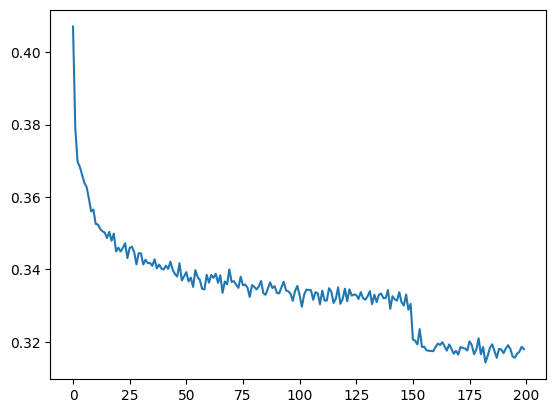

In [ ]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [ ]:
with torch.no_grad():
  for _ in range(20):
    out = []

    context = [0]*block_size

    while True:
      logits = model(torch.tensor(context).unsqueeze(0))
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      out.append(itos[ix])
      context = context[1:] + [ix]
      if ix == 0:
        break

    print(''.join(out))

jastielle.
catine.
air.
alitithira.
liza.
jah.
grancealynna.
jamaurito.
farashton.
sabelia.
cer.
tyre.
dia.
beir.
damelays.
kasca.
jend.
jaxkoimina.
hora.
anneah.


## Improvement 4

Progressive Fusion

In [ ]:
block_size = 8

def build_dataset(names):

  x = []
  y = []
  for name in names:
    context = [0]* block_size
    for ch in name + '.':
      ix = stoi[ch]
      x.append(context)
      y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(x)
  Y = torch.tensor(y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(len(names)*0.8)
n2 = int(len(names)*0.9)
xTr, yTr = build_dataset(names[:n1])
xDev, yDev = build_dataset(names[n1:n2])
xTe, yTe = build_dataset(names[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [ ]:
for x,y in zip(xTr[:10], yTr[:10]):
  print(''.join([itos[ix.item()] for ix in x]),  '-->',  itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o


In [ ]:
embed_size = 10
hidden_size = 200


model = Sequential([
    Embedding(vocab_size, embed_size),
    Flatten(),
    Linear(block_size*embed_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, vocab_size),
])

with torch.no_grad():
  layers[-1].weights *= 0.1 # lowered to avoid imbalanced output probabilities coz that mean higher initial loss, hockey stick issue

parameters = model.parameters()

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

22097


In [ ]:
num_epochs = 200000
batch_size = 32

lossi = []


for i in range(num_epochs):

  ix = torch.randint(0, xTr.shape[0], (batch_size, ))
  xB, yB = xTr[ix], yTr[ix]

  # forward pass
  logits = model(xB)
  loss = F.cross_entropy(logits, yB)

  # backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  # update
  lr = 0.1 if i<150000 else 0.01

  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{num_epochs:7d}: {loss.item():.4f}')
    # print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

  lossi.append(loss.log10().item())

  # break


      0/ 200000: 3.2711
  10000/ 200000: 2.4740
  20000/ 200000: 2.1590
  30000/ 200000: 1.9645
  40000/ 200000: 2.1995
  50000/ 200000: 2.2063
  60000/ 200000: 2.1242
  70000/ 200000: 2.1429
  80000/ 200000: 2.2041
  90000/ 200000: 1.5054
 100000/ 200000: 2.1522
 110000/ 200000: 2.1960
 120000/ 200000: 1.5761
 130000/ 200000: 2.4941
 140000/ 200000: 1.9329
 150000/ 200000: 1.8311
 160000/ 200000: 1.7306
 170000/ 200000: 2.4780
 180000/ 200000: 1.8755
 190000/ 200000: 2.0000


In [ ]:
# put layers into eval mode before running evaluations
for layer in model.layers:
  layer.training = False

In [ ]:
# evaluate
@torch.no_grad()
def split_loss(split):
  x, y = {
      'train': (xTr, yTr),
      'val': (xDev, yDev),
      'test': (xTe, yTe)
  }[split]
  logits = model(x)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9183496236801147
val 2.0228474140167236


In [ ]:
with torch.no_grad():
  for _ in range(20):
    out = []

    context = [0]*block_size

    while True:
      logits = model(torch.tensor(context).unsqueeze(0))
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      out.append(itos[ix])
      context = context[1:] + [ix]
      if ix == 0:
        break

    print(''.join(out))

isayva.
miyah.
jarianni.
maudalynn.
nagry.
joriana.
emman.
adell.
zaalee.
madelot.
emon.
madalyne.
evelys.
adriah.
raeya.
zevaiaca.
mikinz.
marquisa.
joshuke.
rafia.


## Improvement 4

# **WAVENET**

Instead of the entire block of receptive field being condensed into a single linear layer, chunks of the receptive field to be aggregated individually.


WaveNet 2016 from DeepMind https://arxiv.org/abs/1609.03499

Bengio et al. 2003 MLP LM https://www.jmlr.org/papers/volume3/b...


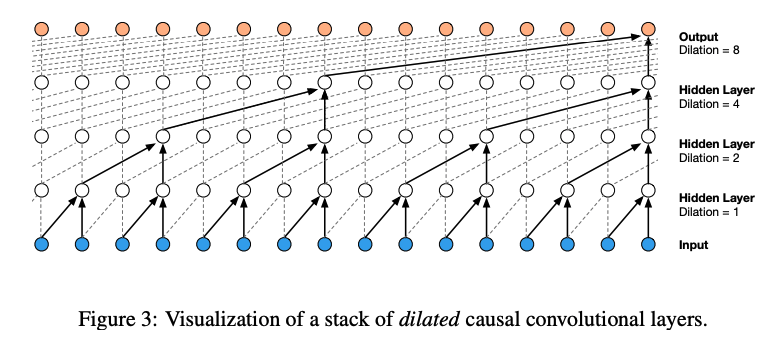

### Useful TidBit

Torch matrix multiplication always multiplies only along the last dimension.

In [ ]:
# Linear layer matrix multiplication sample
(torch.randn((4, 80)) @ torch.randn((80, 200)) + torch.randn(200)).shape

torch.Size([4, 200])

In [ ]:
# RETAINS LEADING DIMENSIONS AFTER MATRIX MULTIPLY
(torch.randn((4, 4, 20)) @ torch.randn((20, 200)) + torch.randn(200)).shape

torch.Size([4, 4, 200])

In [ ]:
# This property will help us "chunkify" the network and leverage the existing linear layer without modification
# (1 2) (3 4) (5 6) (7 8) - bigram groups in the block to be processed in parallel

In [ ]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))


Embedding : (32, 8, 10)
Flatten : (32, 80)
Linear : (32, 200)
BatchNorm1d : (32, 200)
Tanh : (32, 200)
Linear : (32, 27)


In [ ]:
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weights = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.randn(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weights
    if self.bias is not None:
      self.out += self.bias

    return self.out

  def parameters(self):
    return [self.weights] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training =True

    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):

    if self.training:
      bmean = x.mean(0, keepdim=True)
      bvar = x.var(0, keepdim=True)
    else:
      bmean = self.running_mean
      bvar = self.running_var

    xhat = (x - bmean)/torch.sqrt(bvar + self.eps)
    self.out = self.gamma * xhat + self.beta

    if self.training:
      with torch.no_grad():
        self.running_mean = self.momentum*bmean + (1-self.momentum) * self.running_mean
        self.running_var = self.momentum*bvar + (1-self.momentum) * self.running_var

    return self.out

  def parameters(self):
    return [self.gamma] + [self.beta]


class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


class Embedding:
  def __init__(self, vocab_size, embed_size):
    self.weights = torch.randn((vocab_size, embed_size))

  def __call__(self, ix):
    self.out = self.weights[ix]

    return self.out

  def parameters(self):
    return [self.weights]


class FlattenConsecutive:

  def __init__(self, chunk_size):
    self.chunk_size = chunk_size

  def __call__(self, x):
    batch, block, emb =  x.shape
    x = x.view(batch, block//self.chunk_size, emb*self.chunk_size)

    # Alternate technique - concatenate even odd pairs
    # ######################################
    # x = torch.randn(4, 8, 10)
    # x = torch.cat([x[:, ::2, :], x[:, 1::2, :]], dim=2)
    # ######################################

    if x.shape[1] == 1:
      x = x.squeeze(1) # if block_size == chunk_size, the block//self.chunk_size division leaves a superfluous dimension
    self.out = x
    return self.out

  def parameters(self):
    return []


class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
block_size = 8

def build_dataset(names):

  x = []
  y = []
  for name in names:
    context = [0]* block_size
    for ch in name + '.':
      ix = stoi[ch]
      x.append(context)
      y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(x)
  Y = torch.tensor(y)
  print(X.shape, Y.shape)
  return X, Y

n1 = int(len(names)*0.8)
n2 = int(len(names)*0.9)
xTr, yTr = build_dataset(names[:n1])
xDev, yDev = build_dataset(names[n1:n2])
xTe, yTe = build_dataset(names[n2:])

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [ ]:
embed_size = 10
hidden_size = 200
chunk_size = 2


model = Sequential([
    Embedding(vocab_size, embed_size),
    FlattenConsecutive(chunk_size), Linear(chunk_size*embed_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    FlattenConsecutive(chunk_size), Linear(chunk_size*hidden_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    FlattenConsecutive(chunk_size), Linear(chunk_size*hidden_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, vocab_size),
])

with torch.no_grad():
  layers[-1].weights *= 0.1 # lowered to avoid imbalanaced output probabilities coz that mean higher initial loss, hockey stick issue

parameters = model.parameters()

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

170897


In [ ]:
# quick forward

ix = torch.randint(0, xTr.shape[0], (4, ))
xe, ye = xTr[ix], yTr[ix]
logits = model(xe)
print(xe.shape)
xe

torch.Size([4, 8])


tensor([[ 0,  0,  0, 11,  9, 13,  1, 14],
        [ 0,  3,  9, 20, 12,  1, 12, 12],
        [ 0,  0,  0,  0,  0,  0,  0, 10],
        [ 0,  0,  0,  0,  0,  0,  0,  0]])

In [ ]:
for layer in model.layers:
  print(f'{layer.__class__.__name__}: {tuple(layer.out.shape)}')

Embedding: (4, 8, 10)
FlattenConsecutive: (4, 4, 20)
Linear: (4, 4, 200)
BatchNorm1d: (4, 4, 200)
Tanh: (4, 4, 200)
FlattenConsecutive: (4, 2, 400)
Linear: (4, 2, 200)
BatchNorm1d: (4, 2, 200)
Tanh: (4, 2, 200)
FlattenConsecutive: (4, 400)
Linear: (4, 200)
BatchNorm1d: (4, 200)
Tanh: (4, 200)
Linear: (4, 27)


### Change hidden size

Reduce the hidden size to 68 to get approximately the same number of total parameters as our original non-wavenet model i.e. ~22097.

Updated model #parameters = 22397

In [ ]:
embed_size = 10
hidden_size = 68
chunk_size = 2


model = Sequential([
    Embedding(vocab_size, embed_size),
    FlattenConsecutive(chunk_size), Linear(chunk_size*embed_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    FlattenConsecutive(chunk_size), Linear(chunk_size*hidden_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    FlattenConsecutive(chunk_size), Linear(chunk_size*hidden_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, vocab_size),
])

with torch.no_grad():
  layers[-1].weights *= 0.1 # lowered to avoid imbalanaced output probabilities coz that mean higher initial loss, hockey stick issue

parameters = model.parameters()

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

22397


In [ ]:
# quick forward

ix = torch.randint(0, xTr.shape[0], (4, ))
xe, ye = xTr[ix], yTr[ix]
logits = model(xe)
print(xe.shape)
xe

torch.Size([4, 8])


tensor([[15, 14, 14,  1, 20,  8,  1, 14],
        [ 0,  0,  0,  0,  0,  0, 11,  5],
        [ 0,  0,  0,  0,  0,  0,  0, 10],
        [ 0,  0,  0,  0, 18,  9, 22,  5]])

In [ ]:
for layer in model.layers:
  print(f'{layer.__class__.__name__}: {tuple(layer.out.shape)}')

Embedding: (4, 8, 10)
FlattenConsecutive: (4, 4, 20)
Linear: (4, 4, 68)
BatchNorm1d: (4, 4, 68)
Tanh: (4, 4, 68)
FlattenConsecutive: (4, 2, 136)
Linear: (4, 2, 68)
BatchNorm1d: (4, 2, 68)
Tanh: (4, 2, 68)
FlattenConsecutive: (4, 136)
Linear: (4, 68)
BatchNorm1d: (4, 68)
Tanh: (4, 68)
Linear: (4, 27)


In [ ]:
num_epochs = 200000
batch_size = 32

lossi = []


for i in range(num_epochs):

  ix = torch.randint(0, xTr.shape[0], (batch_size, ))
  xB, yB = xTr[ix], yTr[ix]

  # forward pass
  logits = model(xB)
  loss = F.cross_entropy(logits, yB)

  # backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  # update
  lr = 0.1 if i<150000 else 0.01

  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{num_epochs:7d}: {loss.item():.4f}')
    # print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

  lossi.append(loss.log10().item())

  # break

      0/ 200000: 4.1234
  10000/ 200000: 1.8975
  20000/ 200000: 1.9641
  30000/ 200000: 2.1671
  40000/ 200000: 2.1895
  50000/ 200000: 2.2464
  60000/ 200000: 2.3634
  70000/ 200000: 2.4200
  80000/ 200000: 2.1857
  90000/ 200000: 2.1174
 100000/ 200000: 1.7017
 110000/ 200000: 1.8486
 120000/ 200000: 2.1965
 130000/ 200000: 1.7398
 140000/ 200000: 1.5450
 150000/ 200000: 1.9421
 160000/ 200000: 1.7474
 170000/ 200000: 2.1533
 180000/ 200000: 1.8336
 190000/ 200000: 2.1481


In [ ]:
# put layers into eval mode before running evaluations
for layer in model.layers:
  layer.training = False

In [ ]:
# evaluate
@torch.no_grad()
def split_loss(split):
  x, y = {
      'train': (xTr, yTr),
      'val': (xDev, yDev),
      'test': (xTe, yTe)
  }[split]
  logits = model(x)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9392313957214355
val 2.030489683151245


In [ ]:
# sample
with torch.no_grad():
  for _ in range(20):
    out = []

    context = [0]*block_size

    while True:
      logits = model(torch.tensor(context).unsqueeze(0))
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1).item()
      out.append(itos[ix])
      context = context[1:] + [ix]
      if ix == 0:
        break

    print(''.join(out))

danimah.
emmacia.
hosanj.
fishiah.
wayla.
surren.
lethalyn.
najdyn.
hilland.
celiseamellia.
lorien.
trielyn.
antala.
maryson.
kenno.
cayden.
ezabey.
rojhaj.
shammyon.
makynue.


## Improvement 5

Fix BatchNorm bug (technically a feature update since this fix was necessitated by the chunkifying architecture update)

**What's the bug??** Batch stats not calculated correctly

In [ ]:
# quick forward

ix = torch.randint(0, xTr.shape[0], (4, ))
xe, ye = xTr[ix], yTr[ix]
logits = model(xe)
print(xe.shape)
xe

torch.Size([4, 8])


tensor([[ 0,  0,  0,  0, 16, 18,  5, 19],
        [ 5, 26,  5, 11,  9,  5, 12, 12],
        [ 0,  0,  0,  0,  0,  0,  0, 20],
        [ 0,  0,  0,  0, 20, 25, 18,  9]])

In [ ]:
model.layers[2].out.shape

torch.Size([4, 4, 68])

In [ ]:
# batch norm layer out
model.layers[3].out.shape # takes input from a linear layer

torch.Size([4, 4, 68])

In [ ]:
e = torch.randn(32, 4, 68)
emean = e.mean(0, keepdim=True)
evar = e.var(0, keepdim=True)

ehat = (e - emean)/torch.sqrt(evar + 1e-5)

emean.shape, ehat.shape


(torch.Size([1, 4, 68]), torch.Size([32, 4, 68]))

The first linear layer has 68 output neurons, ideally the running mean and running variance should be aggregated over all other dimensions so that each neuron has a singular representative stat --> *WANT [1, 1, 68]*

But, as per the current buggy version, the batchnorm layer maintains 4 different versions of the 68-dim batch statistic --> *HAVE [1, 4, 68]*

This would've been fine in case we had 4 separate linear layers that each bigram-chunk was routed to, but it isn't the case. The same linear layer is used for matrix multiply i.e forward pass of the bigram chunks.

In [ ]:
# Fix

e = torch.randn(32, 4, 68)
emean = e.mean((0, 1), keepdim=True)
evar = e.var((0, 1), keepdim=True)

ehat = (e - emean)/torch.sqrt(evar + 1e-5)

emean.shape, ehat.shape

# shape of the mean indicates that all elements now reduced for a unique batch statistic

(torch.Size([1, 1, 68]), torch.Size([32, 4, 68]))

In [ ]:
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weights = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.randn(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weights
    if self.bias is not None:
      self.out += self.bias

    return self.out

  def parameters(self):
    return [self.weights] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training =True

    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):

    if x.ndim == 2:
      dim = 0  # should've used a different variable name to differentiate from self.dim
    elif x.ndim == 3:
      dim = (0, 1)

    if self.training:
      bmean = x.mean(dim, keepdim=True)
      bvar = x.var(dim, keepdim=True)
    else:
      bmean = self.running_mean
      bvar = self.running_var

    xhat = (x - bmean)/torch.sqrt(bvar + self.eps)
    self.out = self.gamma * xhat + self.beta

    if self.training:
      with torch.no_grad():
        self.running_mean = self.momentum*bmean + (1-self.momentum) * self.running_mean
        self.running_var = self.momentum*bvar + (1-self.momentum) * self.running_var

    return self.out

  def parameters(self):
    return [self.gamma] + [self.beta]


class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []


class Embedding:
  def __init__(self, vocab_size, embed_size):
    self.weights = torch.randn((vocab_size, embed_size))

  def __call__(self, ix):
    self.out = self.weights[ix]

    return self.out

  def parameters(self):
    return [self.weights]


class FlattenConsecutive:

  def __init__(self, chunk_size):
    self.chunk_size = chunk_size

  def __call__(self, x):
    batch, block, emb =  x.shape
    x = x.view(batch, block//self.chunk_size, emb*self.chunk_size)

    # Alternate technique - concatenate even odd pairs
    # ######################################
    # x = torch.randn(4, 8, 10)
    # x = torch.cat([x[:, ::2, :], x[:, 1::2, :]], dim=2)
    # ######################################

    if x.shape[1] == 1:
      x = x.squeeze(1) # if remaining blocks == chunk_size, the division leaves a superfluous dimension
    self.out = x
    return self.out

  def parameters(self):
    return []


class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

Deviation from PyTorch BatchNorm1d - https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html

Channel Dimension is the second dimension(dim=1) in PyTorch, whereas in our implementation the channel dimension is always considerd to be last(dim=2).

Accordingly in PyTorch, the mean would be over the tuples (0,2) and not (0,1) as done here.

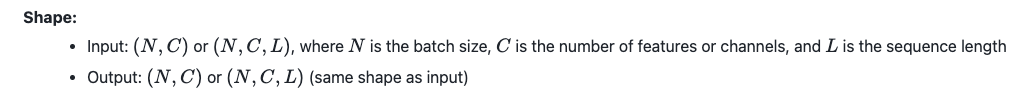


In [ ]:
embed_size = 10
hidden_size = 68
chunk_size = 2


model = Sequential([
    Embedding(vocab_size, embed_size),
    FlattenConsecutive(chunk_size), Linear(chunk_size*embed_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    FlattenConsecutive(chunk_size), Linear(chunk_size*hidden_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    FlattenConsecutive(chunk_size), Linear(chunk_size*hidden_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, vocab_size),
])

with torch.no_grad():
  layers[-1].weights *= 0.1 # lowered to avoid imbalanaced output probabilities coz that mean higher initial loss, hockey stick issue

parameters = model.parameters()

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

22397


In [ ]:
num_epochs = 200000
batch_size = 32

lossi = []


for i in range(num_epochs):

  ix = torch.randint(0, xTr.shape[0], (batch_size, ))
  xB, yB = xTr[ix], yTr[ix]

  # forward pass
  logits = model(xB)
  loss = F.cross_entropy(logits, yB)

  # backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  # update
  lr = 0.1 if i<150000 else 0.01

  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{num_epochs:7d}: {loss.item():.4f}')
    # print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

  lossi.append(loss.log10().item())

  # break

      0/ 200000: 4.3567
  10000/ 200000: 2.2747
  20000/ 200000: 2.0975
  30000/ 200000: 2.0062
  40000/ 200000: 2.2023
  50000/ 200000: 2.0140
  60000/ 200000: 1.7760
  70000/ 200000: 1.9059
  80000/ 200000: 2.1054
  90000/ 200000: 1.9151
 100000/ 200000: 2.0198
 110000/ 200000: 2.3326
 120000/ 200000: 1.7792
 130000/ 200000: 2.4804
 140000/ 200000: 2.3535
 150000/ 200000: 1.8207
 160000/ 200000: 1.9229
 170000/ 200000: 1.6229
 180000/ 200000: 1.8003
 190000/ 200000: 2.0635


In [ ]:
for layer in model.layers:
  print(f'{layer.__class__.__name__}: {tuple(layer.out.shape)}')

Embedding: (32, 8, 10)
FlattenConsecutive: (32, 4, 20)
Linear: (32, 4, 68)
BatchNorm1d: (32, 4, 68)
Tanh: (32, 4, 68)
FlattenConsecutive: (32, 2, 136)
Linear: (32, 2, 68)
BatchNorm1d: (32, 2, 68)
Tanh: (32, 2, 68)
FlattenConsecutive: (32, 136)
Linear: (32, 68)
BatchNorm1d: (32, 68)
Tanh: (32, 68)
Linear: (32, 27)


In [ ]:
model.layers[3].running_mean.shape # more samples get aggregated in calculating the running stats leading to improvement in loss

torch.Size([1, 1, 68])

In [ ]:
# put layers into eval mode before running evaluations
for layer in model.layers:
  layer.training = False

In [ ]:
# evaluate
@torch.no_grad()
def split_loss(split):
  x, y = {
      'train': (xTr, yTr),
      'val': (xDev, yDev),
      'test': (xTe, yTe)
  }[split]
  logits = model(x)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9120763540267944
val 2.017792224884033


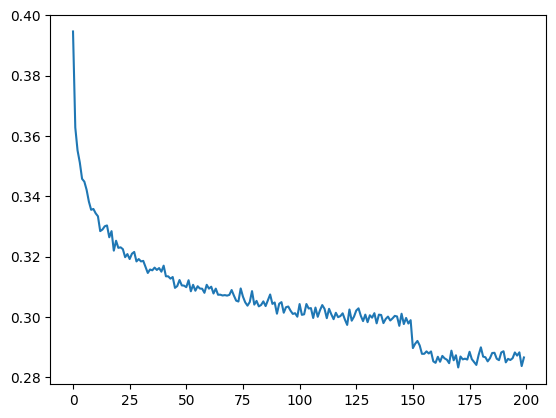

In [ ]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

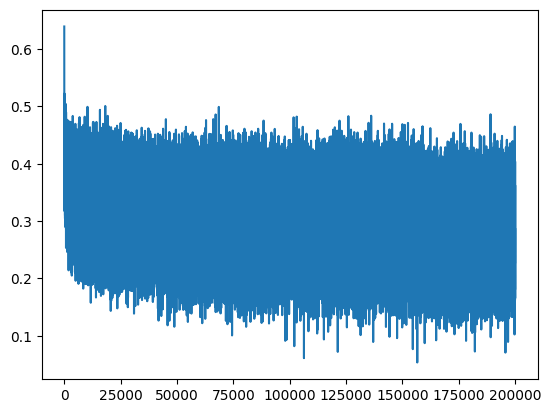

In [ ]:
plt.plot(lossi)

### Bump up the number of parameters


In [ ]:
embed_size = 24
hidden_size = 128
chunk_size = 2


model = Sequential([
    Embedding(vocab_size, embed_size),
    FlattenConsecutive(chunk_size), Linear(chunk_size*embed_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    FlattenConsecutive(chunk_size), Linear(chunk_size*hidden_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    FlattenConsecutive(chunk_size), Linear(chunk_size*hidden_size, hidden_size, bias=False), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, vocab_size),
])

with torch.no_grad():
  layers[-1].weights *= 0.1 # lowered to avoid imbalanaced output probabilities coz that mean higher initial loss, hockey stick issue

parameters = model.parameters()

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

76579


In [ ]:
num_epochs = 200000
batch_size = 32

lossi = []


for i in range(num_epochs):

  ix = torch.randint(0, xTr.shape[0], (batch_size, ))
  xB, yB = xTr[ix], yTr[ix]

  # forward pass
  logits = model(xB)
  loss = F.cross_entropy(logits, yB)

  # backward pass
  for p in parameters:
    p.grad = None

  loss.backward()

  # update
  lr = 0.1 if i<150000 else 0.01

  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i % 10000 == 0:
    print(f'{i:7d}/{num_epochs:7d}: {loss.item():.4f}')
    # print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

  lossi.append(loss.log10().item())

  # break

      0/ 200000: 4.5688
  10000/ 200000: 2.2531
  20000/ 200000: 1.7527
  30000/ 200000: 2.2273
  40000/ 200000: 2.4421
  50000/ 200000: 1.8256
  60000/ 200000: 2.0845
  70000/ 200000: 1.9722
  80000/ 200000: 1.7621
  90000/ 200000: 2.5950
 100000/ 200000: 1.9617
 110000/ 200000: 1.6384
 120000/ 200000: 1.6697
 130000/ 200000: 1.5410
 140000/ 200000: 1.5988
 150000/ 200000: 2.1928
 160000/ 200000: 2.2325
 170000/ 200000: 1.6825
 180000/ 200000: 1.7872
 190000/ 200000: 1.6856


In [ ]:
# put layers into eval mode before running evaluations
for layer in model.layers:
  layer.training = False

In [ ]:
# evaluate
@torch.no_grad()
def split_loss(split):
  x, y = {
      'train': (xTr, yTr),
      'val': (xDev, yDev),
      'test': (xTe, yTe)
  }[split]
  logits = model(x)

  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.767202615737915
val 1.9940412044525146


# Points of Note and Takeaways for Future Directions:



1.   Convolution - more efficient (variable-reuse)
2.   PyTorch unlocked
3.   Development process
        ```
        documention - shapes, layer does?
        make shapes work - shape gymnastics
        prototype in jupy notebook before VSCode
        ```
4.   Convert to dilated convnet
      Residual skip
5.   Experimental harness
        ```
        plots, population level hyperparameter search
        ```
6.   RNNs, GRUs


